In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/THU-MIG/yolov10.git

Cloning into 'yolov10'...
remote: Enumerating objects: 20338, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 20338 (delta 2), reused 0 (delta 0), pack-reused 20334 (from 2)
Receiving objects: 100% (20338/20338), 11.10 MiB | 15.55 MiB/s, done.
Resolving deltas: 100% (14354/14354), done.


In [ ]:
#!wget https://huggingface.co/jameslahm/yolov10n/resolve/main/yolov10n.pt # This command previously failed, YOLO automatically downloaded the weights from another source.

In [ ]:
!gdown '1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R'

Downloading...
From (original): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R
From (redirected): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R&confirm=t&uuid=145a5ae2-d533-466c-afa2-f6a422cc8e26
To: /content/Safety_Helmet_Dataset.zip
100% 33.7M/33.7M [00:01<00:00, 32.1MB/s]


In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10

/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10


In [ ]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       724Mi       8.6Gi       3.0Mi       3.4Gi        11Gi
Swap:             0B          0B          0B


In [ ]:
!pip install -q -r requirements.txt
!pip install -e .

ERROR: Could not find a version that satisfies the requirement torch==2.0.1 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.0.1
Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.1.34-0.editable-py3-none-any.whl size=21685 sha256=44e3d534010bf837c75e3975531d7fa980ca0e9ab17bf91545b54c2212d73880
  Stored in directory: /tmp/pip-ephem-wheel-cache-5rzn66ww/wheels/9f/e4/b1/ab6af8c152da452faca54dae630f8045141791a0ae6d9d4234
Successfully built ultralytics


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install ultralytics

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 92.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 82.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2

In [3]:
from ultralytics import YOLOv10

model = YOLOv10.from_pretrained('jameslahm/yolov10n')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
model.info()

YOLOv10n summary: 385 layers, 2775520 parameters, 2775504 gradients, 8.7 GFLOPs


(385, 2775520, 2775504, 8.741504)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
YAML_PATH = "/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/data.yaml"
EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 32
model.train(data=YAML_PATH,
            epochs=EPOCHS,
            workers=2,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE
            )

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.12.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov10n.yaml, data=/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=None, workers=2, project=None, name=train29, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, au

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


...

/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/ultralytics/engine/trainer.py:276: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning /content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/train/labels.cache... 761 images, 0 backgrounds, 0 corrupt: 100%|██████████| 761/761 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/ultralytics/data/augment.py:846: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/valid/labels.cache... 218 images, 0 backgrounds, 0 corrupt: 100%|██████████| 218/218 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/runs/detect/train29/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 95 weight(decay=0.0), 108 weight(decay=0.0005), 107 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/runs/detect/train29
Starting training for 50 epochs...

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size


       1/50         0G      3.614      4.386      4.296      3.443      8.175      4.404        147        640:   8%|▊         | 2/24 [01:34<17:16, 47.09s/it]

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
BEST_MODEL = "/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/runs/detect/train8/weights/best.pt"
YAML_PATH = "/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/data.yaml"
EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 64
model = YOLO(BEST_MODEL)
model.val(
    data=YAML_PATH,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    split='test'
)

WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camer

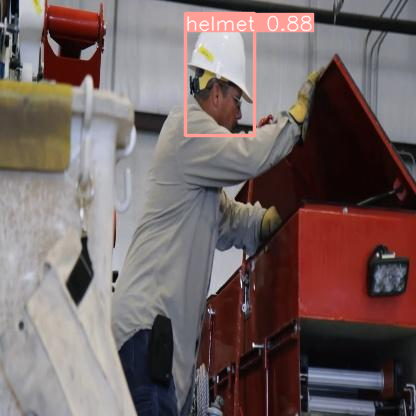

In [7]:
from google.colab.patches import cv2_imshow
BEST_MODEL = "/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/yolov10/runs/detect/train8/weights/best.pt"
model = YOLOv10(BEST_MODEL)
IMAGE_SIZE = 640
image_url = "/content/drive/MyDrive/Colab Notebooks/AIOVN/Module1/Safety_Helmet_Detection/safety_helmet_dataset/test/images/helmet-170-_jpg.rf.c9687ec2af3c86f2be132833dd3aef6c.jpg"
conf_threshold = 0.5
results = model.predict(image_url, imgsz=IMAGE_SIZE, conf=conf_threshold)
print(results[0].boxes)
annotated_img = results[0].plot()
cv2_imshow(annotated_img)